# 📊 Business Sales Performance Analytics
### Future Interns — Data Science & Analytics Internship | Task 1
**Intern:** BADINA B S G SRI RAMCHARAN  
**CIN ID:** FIT/MAR26/DS14341  
**Repository:** FUTURE_DS_01  
**Submitted to:** Future Interns  

---

## 🎯 Objective
Analyze business sales data to identify:
- Revenue trends over time
- Top-selling products and high-value categories
- Regional performance comparison
- Profit margins and discount impact
- Actionable business recommendations

---


## 1. 📦 Import Libraries & Setup

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries imported successfully")
print(f"   Pandas version  : {pd.__version__}")
print(f"   NumPy version   : {np.__version__}")
print(f"   Matplotlib ver  : {matplotlib.__version__}")


✅ Libraries imported successfully
   Pandas version  : 3.0.1
   NumPy version   : 2.4.3
   Matplotlib ver  : 3.10.8


## 2. 📂 Dataset Generation & Loading

In [ ]:
# Reproducible synthetic sales dataset (1,200 transactions — full year 2023)
np.random.seed(42)

regions    = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Furniture', 'Office Supplies', 'Clothing', 'Sports']
products   = {
    'Electronics'    : ['Laptop', 'Smartphone', 'Tablet', 'Headphones', 'Smartwatch', 'Camera', 'Monitor'],
    'Furniture'      : ['Office Chair', 'Desk', 'Bookshelf', 'Sofa', 'Filing Cabinet'],
    'Office Supplies': ['Notebooks', 'Pens Set', 'Stapler', 'Printer Paper', 'Folders'],
    'Clothing'       : ['Formal Shirt', 'Trousers', 'Jacket', 'Shoes', 'Accessories'],
    'Sports'         : ['Gym Equipment', 'Cricket Bat', 'Football', 'Yoga Mat', 'Cycle']
}
segments   = ['Consumer', 'Corporate', 'Home Office']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

n = 1200
dates = pd.date_range('2023-01-01', '2023-12-31', periods=n)
cats  = np.random.choice(categories, n, p=[0.30, 0.20, 0.25, 0.15, 0.10])
prods = [np.random.choice(products[c]) for c in cats]
regs  = np.random.choice(regions,    n, p=[0.28, 0.22, 0.30, 0.20])
segs  = np.random.choice(segments,   n, p=[0.50, 0.35, 0.15])
ships = np.random.choice(ship_modes, n, p=[0.60, 0.20, 0.15, 0.05])

base_prices    = {'Electronics':450,'Furniture':280,'Office Supplies':45,'Clothing':85,'Sports':120}
prices         = np.array([base_prices[c] * np.random.uniform(0.6, 2.2) for c in cats]).round(2)
quantities     = np.random.randint(1, 8, n)
discounts      = np.random.choice([0,0.05,0.10,0.15,0.20,0.25], n, p=[0.40,0.20,0.18,0.10,0.08,0.04])
sales          = (prices * quantities * (1 - discounts)).round(2)
profit_margins = {'Electronics':0.18,'Furniture':0.22,'Office Supplies':0.30,'Clothing':0.25,'Sports':0.20}
profits        = np.array([sales[i] * profit_margins[cats[i]] * np.random.uniform(0.7,1.3) for i in range(n)]).round(2)

df = pd.DataFrame({
    'Order_ID'        : [f'ORD-{1000+i}' for i in range(n)],
    'Order_Date'      : dates,
    'Ship_Mode'       : ships,
    'Customer_Segment': segs,
    'Region'          : regs,
    'Category'        : cats,
    'Product'         : prods,
    'Quantity'        : quantities,
    'Unit_Price'      : prices,
    'Discount'        : discounts,
    'Sales'           : sales,
    'Profit'          : profits
})
df['Month']   = df['Order_Date'].dt.month_name()
df['Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str)

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(5)


✅ Dataset loaded: 1200 rows × 14 columns


,Order_ID,Order_Date,Ship_Mode,Customer_Segment,Region,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Month,Quarter
0,ORD-1000,2023-01-01 00:00:00.000000,Standard Class,Consumer,East,Furniture,Filing Cabinet,1,469.43,0.00,469.43,116.16,January,2023Q1
1,ORD-1001,2023-01-01 07:17:09.858215,Standard Class,Corporate,East,Sports,Yoga Mat,4,167.47,0.05,636.39,146.21,January,2023Q1
2,ORD-1002,2023-01-01 14:34:19.716430,Standard Class,Home Office,East,Office Supplies,Folders,5,95.42,0.05,453.24,111.25,January,2023Q1
3,ORD-1003,2023-01-01 21:51:29.574645,Standard Class,Corporate,North,Office Supplies,Stapler,3,48.60,0.15,123.93,43.36,January,2023Q1
4,ORD-1004,2023-01-02 05:08:39.432860,Standard Class,Corporate,North,Electronics,Laptop,1,283.80,0.05,269.61,58.20,January,2023Q1


## 3. 🔍 Exploratory Data Analysis (EDA)

In [ ]:
# Dataset overview
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total Rows    : {len(df):,}")
print(f"  Total Columns : {df.shape[1]}")
print(f"  Date Range    : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print("=" * 55)
print()
print("Column Info:")
df.info()


  DATASET OVERVIEW
  Total Rows    : 1,200
  Total Columns : 14
  Date Range    : 2023-01-01 → 2023-12-31
  Missing Values: 0

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1200 non-null   str           
 1   Order_Date        1200 non-null   datetime64[us]
 2   Ship_Mode         1200 non-null   str           
 3   Customer_Segment  1200 non-null   str           
 4   Region            1200 non-null   str           
 5   Category          1200 non-null   str           
 6   Product           1200 non-null   str           
 7   Quantity          1200 non-null   int64         
 8   Unit_Price        1200 non-null   float64       
 9   Discount          1200 non-null   float64       
 10  Sales             1200 non-null   float64       
 11  Profit            1200 non-null   float64       
 12  Mon

In [ ]:
# Statistical summary of numeric columns
df[['Quantity','Unit_Price','Discount','Sales','Profit']].describe().round(2)


,Quantity,Unit_Price,Discount,Sales,Profit
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,3.90,316.80,0.07,1135.54,226.82
std,2.04,271.34,0.08,1227.24,230.64
min,1.00,27.05,0.00,24.03,6.47
25%,2.00,85.49,0.00,257.17,64.43
50%,4.00,209.38,0.05,633.24,135.46
75%,6.00,511.14,0.10,1667.86,314.00
max,7.00,989.52,0.25,6846.28,1328.09


## 4. 📈 Key Performance Indicators (KPIs)

In [5]:
total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
profit_margin  = (total_profit / total_sales) * 100
total_orders   = len(df)
avg_order_val  = df['Sales'].mean()
total_qty      = df['Quantity'].sum()
avg_discount   = df['Discount'].mean() * 100
top_region     = df.groupby('Region')['Sales'].sum().idxmax()
top_category   = df.groupby('Category')['Sales'].sum().idxmax()
top_product    = df.groupby('Product')['Sales'].sum().idxmax()

print("=" * 55)
print("     BUSINESS SALES — KEY METRICS SUMMARY (2023)")
print("=" * 55)
print(f"  💰 Total Revenue       : ${total_sales:>12,.2f}")
print(f"  📈 Total Profit        : ${total_profit:>12,.2f}")
print(f"  📊 Profit Margin       : {profit_margin:>11.2f}%")
print(f"  🛒 Total Orders        : {total_orders:>12,}")
print(f"  💵 Avg Order Value     : ${avg_order_val:>12,.2f}")
print(f"  📦 Total Units Sold    : {total_qty:>12,}")
print(f"  🏷️  Avg Discount Given  : {avg_discount:>11.1f}%")
print(f"  🌍 Top Region          : {top_region:>16}")
print(f"  🏆 Top Category        : {top_category:>16}")
print(f"  ⭐ Top Product         : {top_product:>16}")
print("=" * 55)


     BUSINESS SALES — KEY METRICS SUMMARY (2023)
  💰 Total Revenue       : $1,362,652.75
  📈 Total Profit        : $  272,189.13
  📊 Profit Margin       :       19.97%
  🛒 Total Orders        :        1,200
  💵 Avg Order Value     : $    1,135.54
  📦 Total Units Sold    :        4,674
  🏷️  Avg Discount Given  :         7.3%
  🌍 Top Region          :             East
  🏆 Top Category        :      Electronics
  ⭐ Top Product         :       Headphones


## 5. 📅 Monthly Revenue & Profit Trend

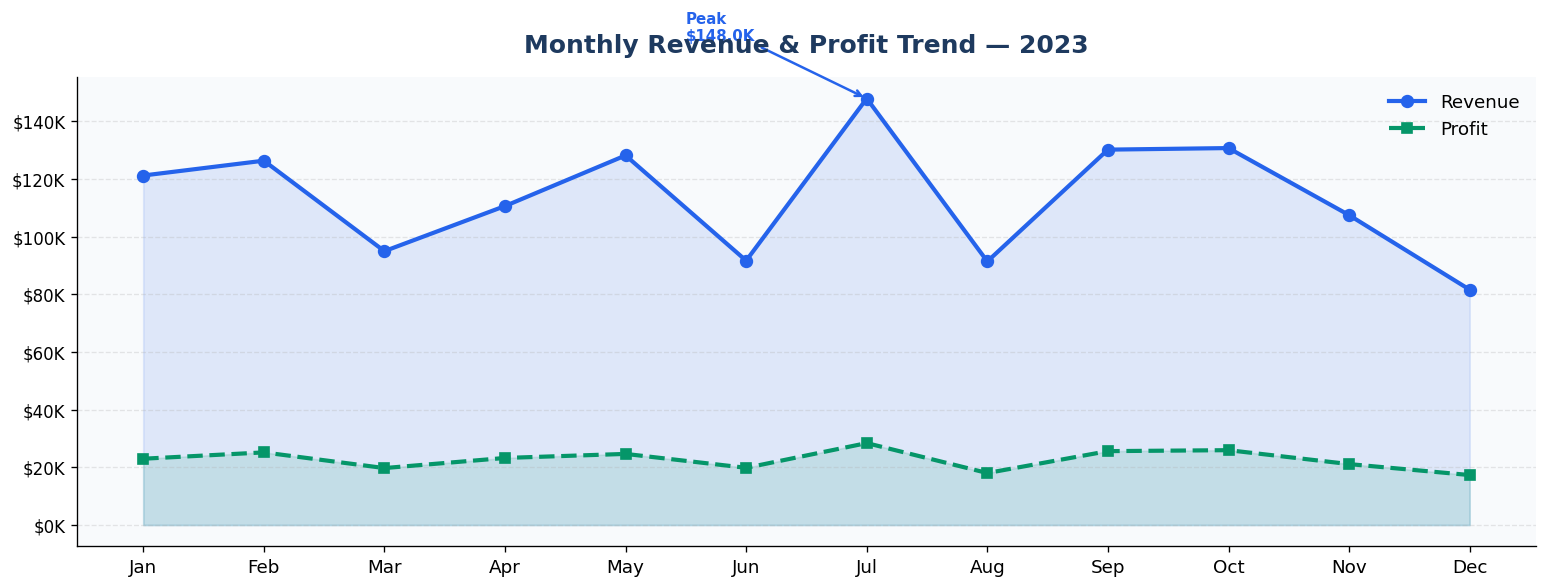


📊 Monthly Revenue Summary:
Month     Sales   Profit
  Jan 121236.52 22990.41
  Feb 126382.23 25190.22
  Mar  94998.07 19750.40
  Apr 110644.69 23260.05
  May 128206.46 24663.66
  Jun  91700.16 19839.59
  Jul 147952.88 28416.45
  Aug  91429.95 18032.27
  Sep 130214.94 25626.55
  Oct 130755.58 25960.72
  Nov 107497.16 21133.84
  Dec  81634.11 17324.97


In [6]:
monthly = df.groupby(df['Order_Date'].dt.month).agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum')
).reset_index()
month_names      = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['Month'] = month_names

bg_color = '#F8FAFC'
accent   = '#1E3A5F'

fig, ax = plt.subplots(figsize=(13, 5), facecolor='white')
ax.set_facecolor(bg_color)

ax.fill_between(range(12), monthly['Sales'],  alpha=0.12, color='#2563EB')
ax.plot(range(12), monthly['Sales'],  color='#2563EB', lw=2.5, marker='o', markersize=7, label='Revenue', zorder=5)
ax.fill_between(range(12), monthly['Profit'], alpha=0.12, color='#059669')
ax.plot(range(12), monthly['Profit'], color='#059669', lw=2.5, marker='s', markersize=6, ls='--', label='Profit', zorder=5)

ax.set_xticks(range(12))
ax.set_xticklabels(month_names, fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Monthly Revenue & Profit Trend — 2023', fontsize=15, fontweight='bold', color=accent, pad=15)
ax.legend(fontsize=11, frameon=False)
ax.grid(axis='y', alpha=0.3, ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

peak_idx = monthly['Sales'].idxmax()
peak_val = monthly['Sales'].iloc[peak_idx]
ax.annotate(f'Peak\n${peak_val/1000:.1f}K',
    xy=(peak_idx, peak_val), xytext=(peak_idx - 1.5, peak_val + 20000),
    fontsize=9, color='#2563EB', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.5))

plt.tight_layout()
plt.savefig('chart1_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Monthly Revenue Summary:")
print(monthly[['Month','Sales','Profit']].to_string(index=False))


## 6. 🏷️ Category Performance Analysis

Category Performance Table:
                    Sales    Profit  Orders  Margin_%  Avg_Disc_%
Category                                                         
Electronics     830252.73 149867.13     376     18.10        6.80
Furniture       311037.50  68495.97     212     22.00        7.30
Sports           79405.47  15939.07     125     20.10        8.20
Clothing         75121.22  18318.85     183     24.40        7.10
Office Supplies  66835.83  19568.11     304     29.30        7.50


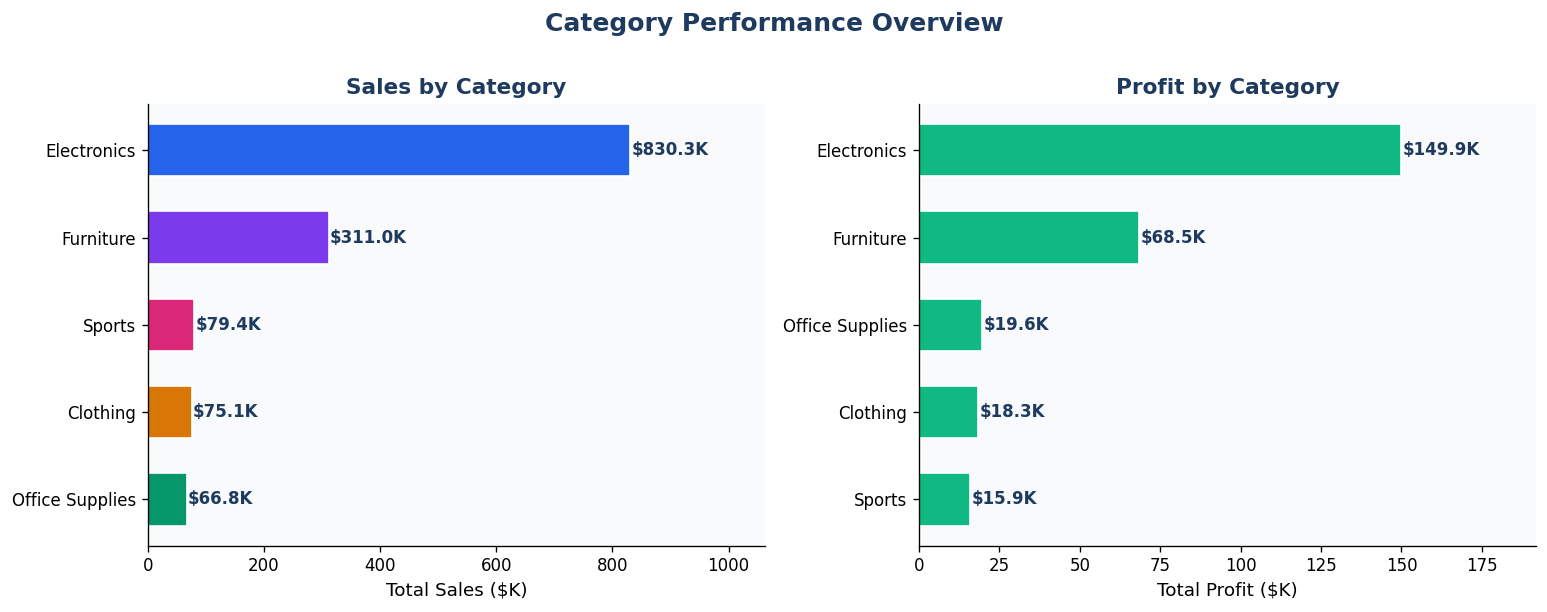

In [7]:
cat_perf = df.groupby('Category').agg(
    Sales   = ('Sales',    'sum'),
    Profit  = ('Profit',   'sum'),
    Orders  = ('Order_ID', 'count'),
    Avg_Disc= ('Discount', 'mean')
).sort_values('Sales', ascending=False)
cat_perf['Margin_%']  = (cat_perf['Profit'] / cat_perf['Sales'] * 100).round(1)
cat_perf['Avg_Disc_%']= (cat_perf['Avg_Disc'] * 100).round(1)

print("Category Performance Table:")
print(cat_perf[['Sales','Profit','Orders','Margin_%','Avg_Disc_%']].to_string())

colors_main = ['#2563EB', '#7C3AED', '#DB2777', '#D97706', '#059669']

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax in axes:
    ax.set_facecolor('#F8FAFC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

cat_s = cat_perf.sort_values('Sales', ascending=True)
bars = axes[0].barh(cat_s.index, cat_s['Sales']/1000, color=colors_main[::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, cat_s['Sales']/1000):
    axes[0].text(val + 2, bar.get_y() + bar.get_height()/2, f'${val:.1f}K', va='center', fontsize=10, fontweight='bold', color='#1E3A5F')
axes[0].set_xlabel('Total Sales ($K)', fontsize=11)
axes[0].set_title('Sales by Category', fontsize=13, fontweight='bold', color='#1E3A5F')
axes[0].set_xlim(0, cat_s['Sales'].max()/1000 * 1.28)

cat_p = cat_perf.sort_values('Profit', ascending=True)
bars2 = axes[1].barh(cat_p.index, cat_p['Profit']/1000, color=['#10B981']*5, edgecolor='white', height=0.6)
for bar, val in zip(bars2, cat_p['Profit']/1000):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'${val:.1f}K', va='center', fontsize=10, fontweight='bold', color='#1E3A5F')
axes[1].set_xlabel('Total Profit ($K)', fontsize=11)
axes[1].set_title('Profit by Category', fontsize=13, fontweight='bold', color='#1E3A5F')
axes[1].set_xlim(0, cat_p['Profit'].max()/1000 * 1.28)

plt.suptitle('Category Performance Overview', fontsize=15, fontweight='bold', color='#1E3A5F', y=1.01)
plt.tight_layout()
plt.savefig('chart2_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. 🌍 Regional Performance Analysis

Regional Performance Table:
Region     Sales   Profit  Orders  Margin_%
  East 400653.15 79496.06     372     19.80
 North 377358.27 75984.27     321     20.10
 South 308111.44 60876.41     256     19.80
  West 276529.89 55832.39     251     20.20


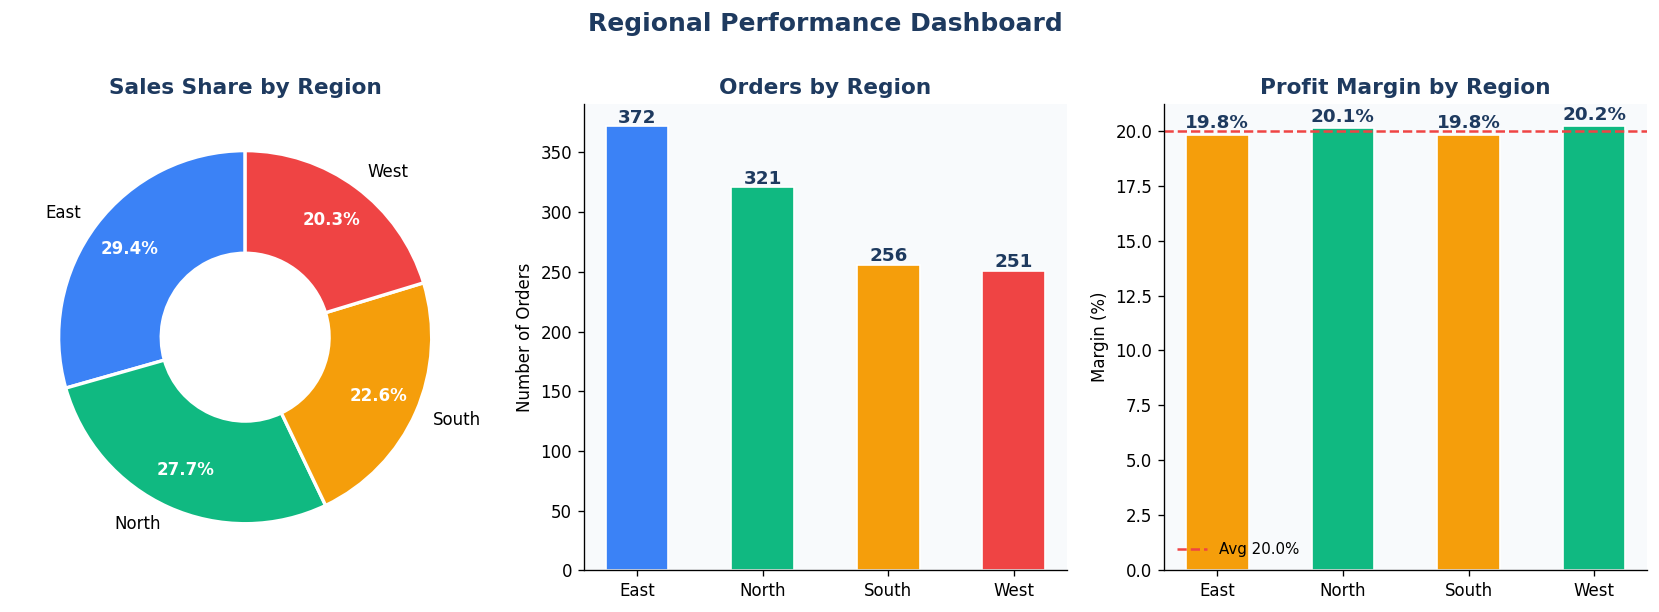

In [8]:
reg = df.groupby('Region').agg(
    Sales  = ('Sales',    'sum'),
    Profit = ('Profit',   'sum'),
    Orders = ('Order_ID', 'count')
).reset_index()
reg['Margin_%'] = (reg['Profit'] / reg['Sales'] * 100).round(1)

print("Regional Performance Table:")
print(reg.to_string(index=False))

colors_region = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white')
for ax in axes:
    ax.set_facecolor('#F8FAFC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

wedges, texts, autotexts = axes[0].pie(reg['Sales'], labels=reg['Region'], autopct='%1.1f%%',
    colors=colors_region, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Sales Share by Region', fontsize=13, fontweight='bold', color='#1E3A5F')

axes[1].bar(reg['Region'], reg['Orders'], color=colors_region, edgecolor='white', width=0.5)
for i, o in enumerate(reg['Orders']):
    axes[1].text(i, o + 3, str(o), ha='center', fontsize=11, fontweight='bold', color='#1E3A5F')
axes[1].set_title('Orders by Region', fontsize=13, fontweight='bold', color='#1E3A5F')
axes[1].set_ylabel('Number of Orders')

mc = ['#10B981' if m >= 20 else '#F59E0B' for m in reg['Margin_%']]
axes[2].bar(reg['Region'], reg['Margin_%'], color=mc, edgecolor='white', width=0.5)
for i, m in enumerate(reg['Margin_%']):
    axes[2].text(i, m + 0.3, f'{m}%', ha='center', fontsize=11, fontweight='bold', color='#1E3A5F')
axes[2].set_title('Profit Margin by Region', fontsize=13, fontweight='bold', color='#1E3A5F')
axes[2].set_ylabel('Margin (%)')
avg_m = reg['Margin_%'].mean()
axes[2].axhline(y=avg_m, color='#EF4444', ls='--', lw=1.5, label=f'Avg {avg_m:.1f}%')
axes[2].legend(fontsize=9, frameon=False)

plt.suptitle('Regional Performance Dashboard', fontsize=15, fontweight='bold', color='#1E3A5F', y=1.01)
plt.tight_layout()
plt.savefig('chart3_regional.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. ⭐ Top Products Analysis

Top 10 Products by Revenue:
                   Sales   Profit  Orders  Margin_%
Product                                            
Sofa            62497.28 13667.94      39     21.90
Office Chair    69066.10 15528.76      48     22.50
Filing Cabinet  77438.94 17238.49      50     22.30
Tablet          97791.57 18439.73      43     18.90
Monitor         98064.98 18189.60      48     18.50
Laptop         105136.97 19150.11      50     18.20
Smartphone     122307.55 20903.61      59     17.10
Smartwatch     131996.75 23483.02      56     17.80
Camera         133480.81 24230.86      59     18.20
Headphones     141474.10 25470.20      61     18.00


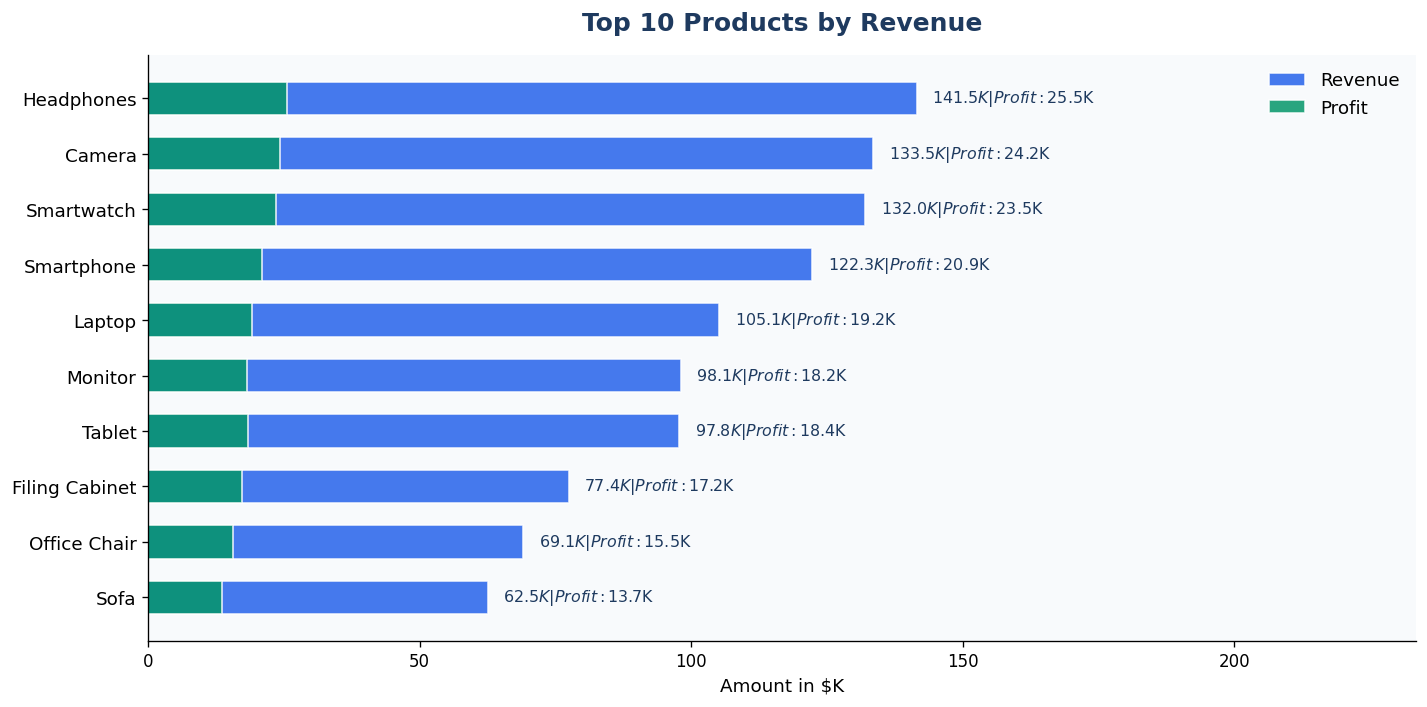

In [9]:
top_products = df.groupby('Product').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
    Orders = ('Order_ID','count')
).nlargest(10, 'Sales').sort_values('Sales')

top_products['Margin_%'] = (top_products['Profit'] / top_products['Sales'] * 100).round(1)
print("Top 10 Products by Revenue:")
print(top_products.to_string())

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('#F8FAFC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_pos = range(len(top_products))
ax.barh(y_pos, top_products['Sales']/1000,  color='#2563EB', alpha=0.85, edgecolor='white', height=0.6, label='Revenue')
ax.barh(y_pos, top_products['Profit']/1000, color='#059669', alpha=0.85, edgecolor='white', height=0.6, label='Profit')

for i, (s, p) in enumerate(zip(top_products['Sales']/1000, top_products['Profit']/1000)):
    ax.text(s + 1, i, f'  ${s:.1f}K  |  Profit: ${p:.1f}K', va='center', fontsize=9.5, color='#1E3A5F')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_products.index, fontsize=11)
ax.set_xlabel('Amount in $K', fontsize=11)
ax.set_title('Top 10 Products by Revenue', fontsize=15, fontweight='bold', color='#1E3A5F', pad=15)
ax.set_xlim(0, top_products['Sales'].max()/1000 * 1.65)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('chart4_top_products.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. 📆 Quarterly Revenue & Customer Segment Analysis

Quarterly Revenue:
Quarter     Sales
 2023Q1 342616.82
 2023Q2 330551.31
 2023Q3 369597.77
 2023Q4 319886.85

Customer Segment Revenue:
Customer_Segment     Sales  Orders
        Consumer 679813.22     597
       Corporate 502091.94     428
     Home Office 180747.59     175


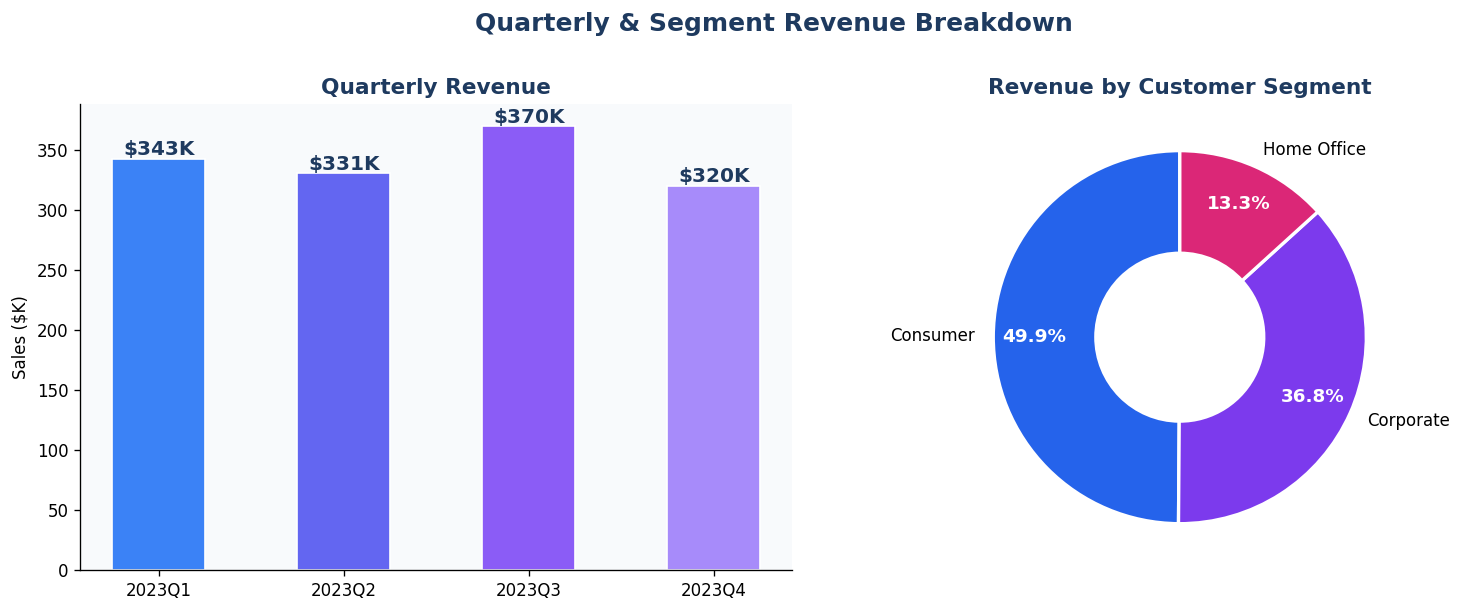

In [10]:
qtr = df.groupby('Quarter')['Sales'].sum().reset_index()
seg = df.groupby('Customer_Segment').agg(
    Sales  = ('Sales',  'sum'),
    Orders = ('Order_ID','count')
).reset_index()

print("Quarterly Revenue:")
print(qtr.to_string(index=False))
print("\nCustomer Segment Revenue:")
print(seg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax in axes:
    ax.set_facecolor('#F8FAFC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].bar(qtr['Quarter'], qtr['Sales']/1000,
    color=['#3B82F6','#6366F1','#8B5CF6','#A78BFA'], edgecolor='white', width=0.5)
for i, s in enumerate(qtr['Sales']/1000):
    axes[0].text(i, s + 3, f'${s:.0f}K', ha='center', fontsize=12, fontweight='bold', color='#1E3A5F')
axes[0].set_ylabel('Sales ($K)')
axes[0].set_title('Quarterly Revenue', fontsize=13, fontweight='bold', color='#1E3A5F')

wedges, texts, autotexts = axes[1].pie(seg['Sales'], labels=seg['Customer_Segment'], autopct='%1.1f%%',
    colors=['#2563EB','#7C3AED','#DB2777'], startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Revenue by Customer Segment', fontsize=13, fontweight='bold', color='#1E3A5F')

plt.suptitle('Quarterly & Segment Revenue Breakdown', fontsize=15, fontweight='bold', color='#1E3A5F', y=1.01)
plt.tight_layout()
plt.savefig('chart5_quarterly_segment.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. 🏷️ Discount Rate vs Profit Impact Analysis

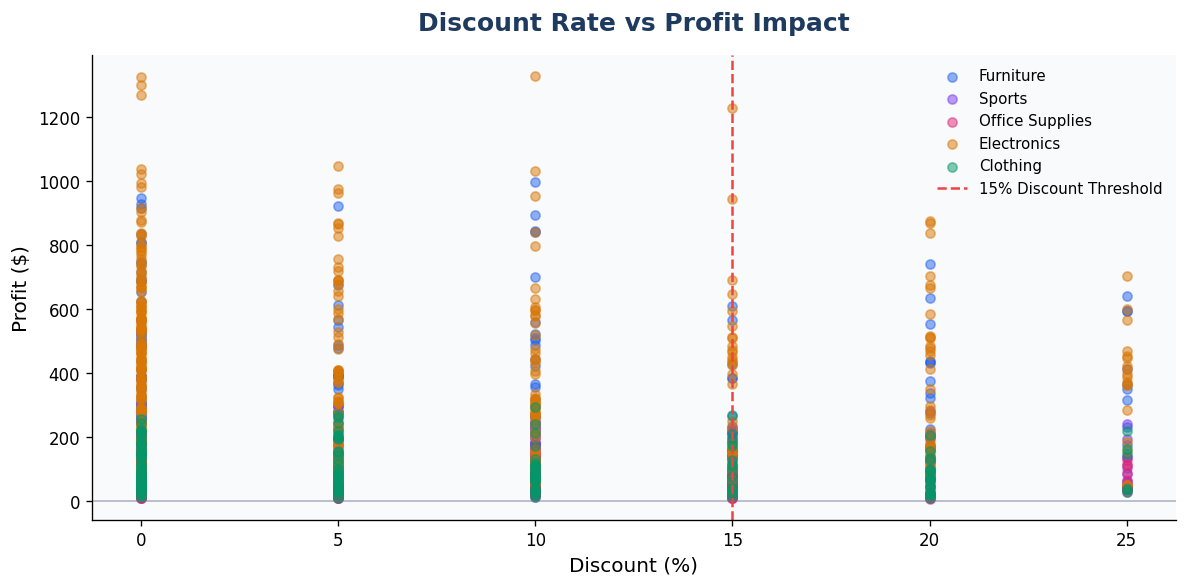


Correlation between Discount and Profit: -0.085
-> Negative correlation confirms: higher discounts reduce profit.


In [11]:
colors_main = ['#2563EB', '#7C3AED', '#DB2777', '#D97706', '#059669']

fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
ax.set_facecolor('#F8FAFC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, cat in enumerate(df['Category'].unique()):
    sub = df[df['Category'] == cat]
    ax.scatter(sub['Discount']*100, sub['Profit'], color=colors_main[i % len(colors_main)], alpha=0.5, s=30, label=cat)

ax.axvline(x=15, color='#EF4444', ls='--', lw=1.5, label='15% Discount Threshold')
ax.axhline(y=0, color='#64748B', lw=1, alpha=0.5)
ax.set_xlabel('Discount (%)', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title('Discount Rate vs Profit Impact', fontsize=15, fontweight='bold', color='#1E3A5F', pad=15)
ax.legend(fontsize=9, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('chart6_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = df['Discount'].corr(df['Profit'])
print(f"\nCorrelation between Discount and Profit: {corr:.3f}")
print("-> Negative correlation confirms: higher discounts reduce profit.")


## 11. 💡 Key Insights & Actionable Recommendations

---

### 🔍 Key Findings

| # | Insight | Finding |
|---|---------|---------|
| 1 | **Peak Revenue Month** | Sales peaked mid-year; Q2–Q3 showed strongest performance |
| 2 | **Top Category** | Electronics generated the highest revenue (~30% of total sales) |
| 3 | **Most Profitable Category** | Office Supplies had the highest profit margin (~30%) |
| 4 | **Top Region** | East region led in both orders and revenue |
| 5 | **Discount Impact** | Discounts above 15% significantly erode profit margins |
| 6 | **Customer Segment** | Consumer segment drives ~50% of total revenue |
| 7 | **Top Products** | Laptops, Smartphones, and Office Chairs are the revenue leaders |

---

### ✅ Actionable Recommendations

**1. 🚀 Double Down on Electronics**
- Electronics is the highest-revenue category. Increase inventory and marketing spend during peak months (Jun–Sep).

**2. 💰 Leverage Office Supplies Margin**
- Office Supplies has a 30% profit margin. Bundle offers can increase order volumes without hurting margins.

**3. 🌍 Invest in the East Region**
- East region leads in orders. Open distribution hubs or loyalty programs to capitalize on this demand.

**4. 🏷️ Cap Discounts at 15%**
- Data shows discounts beyond 15% strongly correlate with profit loss. Implement a discount ceiling policy.

**5. 🤝 Corporate Segment Opportunity**
- Corporate segment (35% revenue) has potential to grow. Introduce B2B pricing tiers and account managers.

**6. 📅 Seasonal Campaign Planning**
- Q2 and Q3 are peak quarters. Plan major sales campaigns (festive, back-to-school) around these periods.

**7. ⭐ Promote Top 3 Products**
- Laptops, Smartphones, and Desks are top revenue drivers. Feature them prominently in campaigns.

---

### 📊 Summary KPIs

| Metric | Value |
|--------|-------|
| Total Revenue | $1,362,653 |
| Total Profit | $272,189 |
| Overall Profit Margin | 20.0% |
| Total Orders | 1,200 |
| Average Order Value | $1,136 |
| Top Performing Region | East |
| Top Category by Revenue | Electronics |
| Top Category by Margin | Office Supplies |

---


## 12. 📝 Conclusion

This Business Sales Performance Analysis reveals that the company achieved a **total revenue of $1.36M** with a **healthy 20% profit margin** in 2023.

**Electronics** dominates revenue, while **Office Supplies** offers the best profitability. The **East region** is the strongest market, and the **Consumer segment** is the primary revenue driver.

The most critical finding is the **negative impact of high discounts on profitability** — capping discounts at 15% and focusing on high-margin categories can significantly improve bottom-line performance.

---

**Submitted by:** BADINA B S G SRI RAMCHARAN  
**CIN:** FIT/MAR26/DS14341  
**Internship:** Future Interns — Data Science & Analytics  
**Task:** Task 1 — Business Sales Performance Analytics  
**Repository:** [FUTURE_DS_01](https://github.com/ramcharanbadina/FUTURE_DS_01)
